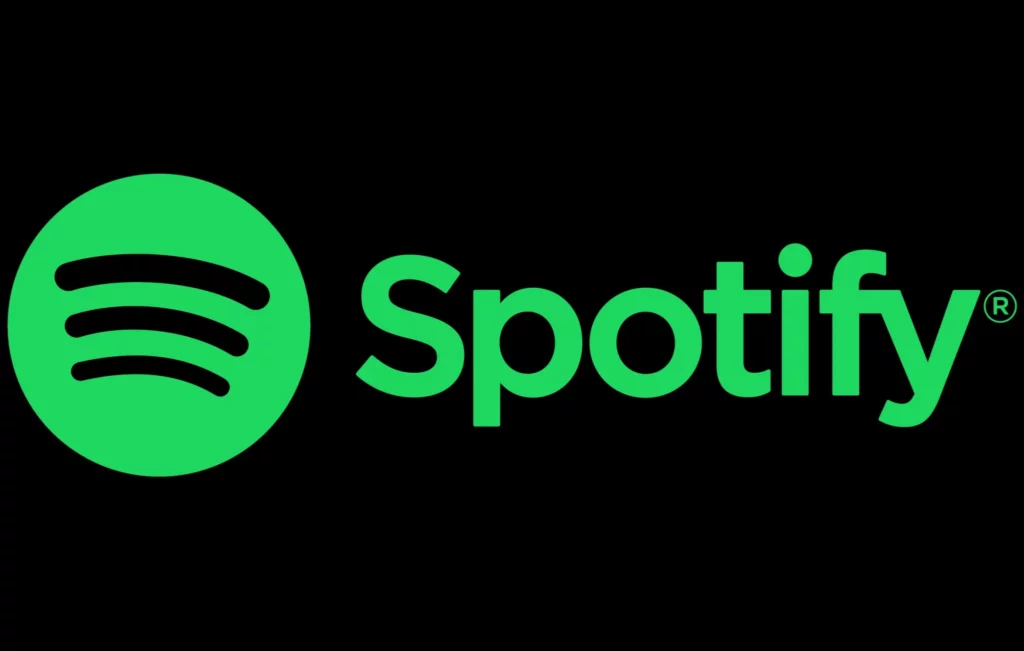

In [ ]:
!pip install fastapi uvicorn colabcode

Requested uvicorn from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b08d6c23051/uvicorn-0.13.1-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Please use pip<24.1 if you need to use this version.
INFO: pip is looking at multiple versions of colabcode to determine which version is compatible with other requirements. This could take a while.
  Using cached uvicorn-0.13.1-py3-none-any.whl.metadata (4.6 kB)
Requested uvicorn from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b08d6c23051/uvicorn-0.13.1-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Please use pip<24.1 if you need to use this version.
  Using cached uvicorn-0.13.1-py3-none-any.whl.

In [ ]:
!pip install streamlit pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.8 MB/s eta 0:00:00


Spotify Music Genre Classificaton 🎧


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import PowerTransformer
import joblib as jb

Loading the Dataset ⏳

In [ ]:
music_dataset = pd.read_csv('Spotify Dataset.csv', nrows = 20000)
music_dataset

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,6DCXwlDxgCDXEFWlNEgWoj,Rotlaus,Når vi to blir en,Når vi to blir en,42,215000,False,0.558,0.8980,...,-5.324,1,0.0301,0.0096,0.000000,0.3800,0.737,87.015,4,country
19996,19996,3Brvbk03WC7yu1LgKwWG3L,Salebarbes,Gin à l'eau salée,Gin à l'eau salée,41,187982,False,0.494,0.9660,...,-5.578,1,0.0724,0.0158,0.000000,0.1780,0.566,172.281,4,country
19997,19997,6WnSqAp4o9ii13vVk4iM1t,Sawyer Brown,Best Of,Some Girls Do,40,194320,False,0.640,0.8520,...,-6.406,1,0.0280,0.0907,0.000000,0.1510,0.903,139.949,4,country
19998,19998,7plI8XMJN3vIlPpSQAeIuR,Upchurch,Creeker,Blow My Smoke,41,202866,True,0.449,0.8480,...,-5.584,0,0.0669,0.0152,0.000000,0.8820,0.643,150.039,4,country


In [ ]:
data_samples = 50000
num_classes = 113

data_points = data_samples / num_classes
print('Total number of data points for each class:', data_points)

dataset_point = []
for i in music_dataset['track_genre'].unique():
    genre_data = music_dataset[music_dataset['track_genre'] == i]
    if len(genre_data) >= data_points:
        dataset_point.append(genre_data.sample(n=int(data_points), random_state=42))
    else:
        dataset_point.append(genre_data)

final_dataset = pd.concat(dataset_point).sample(frac=1, random_state=42).reset_index(drop=True)

Total number of data points for each class: 442.4778761061947


In [ ]:
music_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20000 non-null  int64  
 1   track_id          20000 non-null  object 
 2   artists           20000 non-null  object 
 3   album_name        20000 non-null  object 
 4   track_name        20000 non-null  object 
 5   popularity        20000 non-null  int64  
 6   duration_ms       20000 non-null  int64  
 7   explicit          20000 non-null  bool   
 8   danceability      20000 non-null  float64
 9   energy            20000 non-null  float64
 10  key               20000 non-null  int64  
 11  loudness          20000 non-null  float64
 12  mode              20000 non-null  int64  
 13  speechiness       20000 non-null  float64
 14  acousticness      20000 non-null  float64
 15  instrumentalness  20000 non-null  float64
 16  liveness          20000 non-null  float6

In [ ]:
music_dataset.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,31.492900,2.357796e+05,0.557083,0.590821,5.309650,-9.432064,0.677900,0.102838,0.382859,0.212239,0.215680,0.467865,120.425363,3.877350
std,5773.647028,21.698848,1.370552e+05,0.175920,0.266932,3.547632,5.592897,0.467293,0.179171,0.358857,0.348208,0.201619,0.263519,29.539170,0.460345
min,0.000000,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.808000,0.000000,0.000000,0.000000,0.000000,0.011600,0.000000,0.000000,0.000000
25%,4999.750000,16.000000,1.717730e+05,0.446000,0.393000,2.000000,-11.430250,0.000000,0.034100,0.021800,0.000000,0.096900,0.248000,98.019250,4.000000
50%,9999.500000,29.000000,2.182400e+05,0.569000,0.621000,5.000000,-7.954000,1.000000,0.045300,0.282000,0.000210,0.127000,0.451000,120.222500,4.000000
75%,14999.250000,49.000000,2.726122e+05,0.683000,0.825000,8.000000,-5.698750,1.000000,0.075500,0.740000,0.346500,0.264000,0.680000,138.835250,4.000000
max,19999.000000,93.000000,4.789026e+06,0.981000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,0.995000,0.995000,0.995000,243.372000,5.000000


Preprocessing the Data 🛠️

In [ ]:
print(music_dataset.isnull().sum())
print('\nthe number of null values is: ', music_dataset.isnull().sum().sum())

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

the number of null values is:  0


In [ ]:
print(music_dataset.nunique())
print('\nthe number of unique values is: ', music_dataset.nunique().sum())

Unnamed: 0          20000
track_id            18905
artists              6169
album_name          10024
track_name          16397
popularity             90
duration_ms         14862
explicit                2
danceability          956
energy               1495
key                    12
loudness            10489
mode                    2
speechiness          1352
acousticness         3658
instrumentalness     3952
liveness             1586
valence              1477
tempo               14331
time_signature          5
track_genre            20
dtype: int64

the number of unique values is:  125784


In [ ]:
print(music_dataset.duplicated())
print('\nthe number of duplicated values is: ', music_dataset.duplicated().sum())

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

the number of duplicated values is:  0


In [ ]:
#now removing the useless features in the dataset
music_dataset.drop(['track_id', 'artists', 'album_name', 'track_name'], axis = 1, inplace = True)

In [ ]:
music_dataset

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,42,215000,False,0.558,0.8980,7,-5.324,1,0.0301,0.0096,0.000000,0.3800,0.737,87.015,4,country
19996,19996,41,187982,False,0.494,0.9660,5,-5.578,1,0.0724,0.0158,0.000000,0.1780,0.566,172.281,4,country
19997,19997,40,194320,False,0.640,0.8520,2,-6.406,1,0.0280,0.0907,0.000000,0.1510,0.903,139.949,4,country
19998,19998,41,202866,True,0.449,0.8480,4,-5.584,0,0.0669,0.0152,0.000000,0.8820,0.643,150.039,4,country


In [ ]:
music_dataset.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [ ]:
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,42,215000,False,0.558,0.8980,7,-5.324,1,0.0301,0.0096,0.000000,0.3800,0.737,87.015,4,country
19996,41,187982,False,0.494,0.9660,5,-5.578,1,0.0724,0.0158,0.000000,0.1780,0.566,172.281,4,country
19997,40,194320,False,0.640,0.8520,2,-6.406,1,0.0280,0.0907,0.000000,0.1510,0.903,139.949,4,country
19998,41,202866,True,0.449,0.8480,4,-5.584,0,0.0669,0.0152,0.000000,0.8820,0.643,150.039,4,country


In [ ]:
original_column_names = music_dataset['track_genre']
original_column_names

,track_genre
0,acoustic
1,acoustic
2,acoustic
3,acoustic
4,acoustic
...,...
19995,country
19996,country
19997,country
19998,country


In [ ]:
#now label encoding
le = LabelEncoder()
music_dataset['explicit'] = le.fit_transform(music_dataset['explicit'])
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,42,215000,0,0.558,0.8980,7,-5.324,1,0.0301,0.0096,0.000000,0.3800,0.737,87.015,4,country
19996,41,187982,0,0.494,0.9660,5,-5.578,1,0.0724,0.0158,0.000000,0.1780,0.566,172.281,4,country
19997,40,194320,0,0.640,0.8520,2,-6.406,1,0.0280,0.0907,0.000000,0.1510,0.903,139.949,4,country
19998,41,202866,1,0.449,0.8480,4,-5.584,0,0.0669,0.0152,0.000000,0.8820,0.643,150.039,4,country


In [ ]:
#combining features using mutual relations
music_dataset['energy_tempo'] = music_dataset['energy'] * music_dataset['tempo']
music_dataset['dance_valence'] = music_dataset['danceability'] * music_dataset['valence']
music_dataset['speech_acoustic'] = music_dataset['speechiness'] / (music_dataset['acousticness'] + 0.001)
music_dataset['loudness_instrumental'] = music_dataset['loudness'] * (1 - music_dataset['instrumentalness'])
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_tempo,dance_valence,speech_acoustic,loudness_instrumental
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,40.529737,0.483340,4.307229,-6.745993
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,12.863174,0.112140,0.082486,-17.234904
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,27.403188,0.052560,0.263981,-9.734000
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,10.831704,0.038038,0.040066,-18.513691
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,53.137407,0.103206,0.111915,-9.681000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,42,215000,0,0.558,0.8980,7,-5.324,1,0.0301,0.0096,0.000000,0.3800,0.737,87.015,4,country,78.139470,0.411246,2.839623,-5.324000
19996,41,187982,0,0.494,0.9660,5,-5.578,1,0.0724,0.0158,0.000000,0.1780,0.566,172.281,4,country,166.423446,0.279604,4.309524,-5.578000
19997,40,194320,0,0.640,0.8520,2,-6.406,1,0.0280,0.0907,0.000000,0.1510,0.903,139.949,4,country,119.236548,0.577920,0.305344,-6.406000
19998,41,202866,1,0.449,0.8480,4,-5.584,0,0.0669,0.0152,0.000000,0.8820,0.643,150.039,4,country,127.233072,0.288707,4.129630,-5.584000


In [ ]:
# Drop original features that we've combined
music_dataset.drop(['energy', 'tempo', 'danceability', 'valence', 'speechiness', 'acousticness', 'loudness', 'instrumentalness'], axis=1, inplace=True)

In [ ]:
music_dataset

,popularity,duration_ms,explicit,key,mode,liveness,time_signature,track_genre,energy_tempo,dance_valence,speech_acoustic,loudness_instrumental
0,73,230666,0,1,0,0.3580,4,acoustic,40.529737,0.483340,4.307229,-6.745993
1,55,149610,0,1,1,0.1010,4,acoustic,12.863174,0.112140,0.082486,-17.234904
2,57,210826,0,0,1,0.1170,4,acoustic,27.403188,0.052560,0.263981,-9.734000
3,71,201933,0,0,1,0.1320,3,acoustic,10.831704,0.038038,0.040066,-18.513691
4,82,198853,0,2,1,0.0829,4,acoustic,53.137407,0.103206,0.111915,-9.681000
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,42,215000,0,7,1,0.3800,4,country,78.139470,0.411246,2.839623,-5.324000
19996,41,187982,0,5,1,0.1780,4,country,166.423446,0.279604,4.309524,-5.578000
19997,40,194320,0,2,1,0.1510,4,country,119.236548,0.577920,0.305344,-6.406000
19998,41,202866,1,4,0,0.8820,4,country,127.233072,0.288707,4.129630,-5.584000


In [ ]:
# Map all the 113 genres (classes) to the supertypes of genres
genre_mapping = {
    'rock': ['rock', 'hard-rock', 'psych-rock', 'punk-rock', 'rock-n-roll', 'rockabilly', 'grunge', 'alternative', 'alt-rock'],
    'pop': ['pop', 'power-pop', 'k-pop', 'j-pop', 'cantopop', 'mandopop', 'indie-pop', 'synth-pop'],
    'metal': ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore'],
    'electronic': ['electronic', 'edm', 'electro', 'dubstep', 'techno', 'trance', 'house', 'deep-house', 'drum-and-bass', 'dub', 'detroit-techno', 'minimal-techno', 'progressive-house', 'chicago-house'],
    'hiphop': ['hip-hop', 'trip-hop', 'r-n-b'],
    'jazz': ['jazz', 'blues'],
    'classical': ['classical', 'opera'],
    'folk': ['folk', 'singer-songwriter', 'country', 'bluegrass', 'honky-tonk'],
    'reggae': ['reggae', 'reggaeton', 'dancehall', 'ska'],
    'latin': ['latin', 'latino', 'salsa', 'samba', 'tango', 'brazil', 'forro', 'pagode', 'sertanejo'],
    'world': ['world-music', 'afrobeat', 'indian', 'iranian', 'turkish', 'spanish', 'french', 'german', 'malay', 'swedish'],
    'other': ['ambient', 'chill', 'comedy', 'disco', 'disney', 'funk', 'gospel', 'goth', 'happy', 'idm', 'j-dance', 'j-idol', 'j-rock', 'kids', 'mpb', 'new-age', 'party', 'piano', 'pop-film', 'romance', 'sad', 'show-tunes', 'sleep', 'soul', 'study']
}

In [ ]:
# Create inverse mapping for lookup
inv_genre_mapping = {v: k for k, values in genre_mapping.items() for v in values}

In [ ]:
# Map original genres to supertypes
music_dataset['genre_supertype'] = music_dataset['track_genre'].map(inv_genre_mapping)
music_dataset['genre_supertype'].fillna('other', inplace=True)

/tmp/ipython-input-3413459737.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  music_dataset['genre_supertype'].fillna('other', inplace=True)


In [ ]:
# Now label encode the supertypes
music_dataset['track_genre'] = le.fit_transform(music_dataset['genre_supertype'])
music_dataset.drop('genre_supertype', axis=1, inplace=True)

In [ ]:
# Handle class imbalance with SMOTE
X = music_dataset.drop('track_genre', axis=1)
y = music_dataset['track_genre']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
music_dataset = pd.concat([X_res, y_res], axis=1)

Exploratory Data Analysis 🧐📊

<Figure size 1000x500 with 0 Axes>

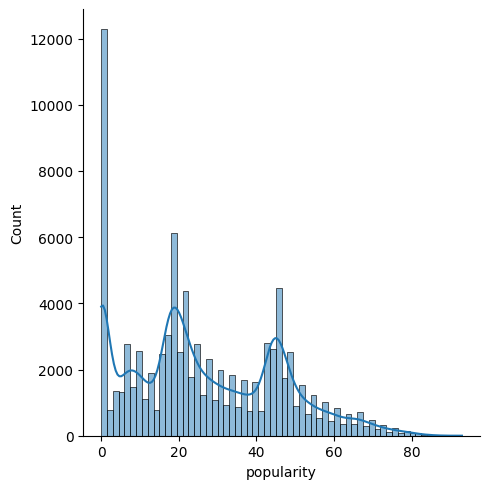

<Figure size 1000x500 with 0 Axes>

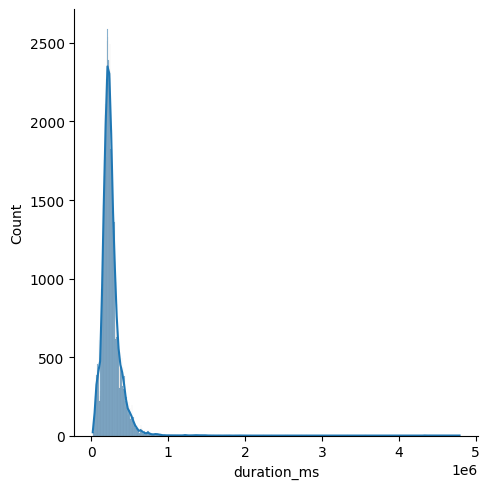

<Figure size 1000x500 with 0 Axes>

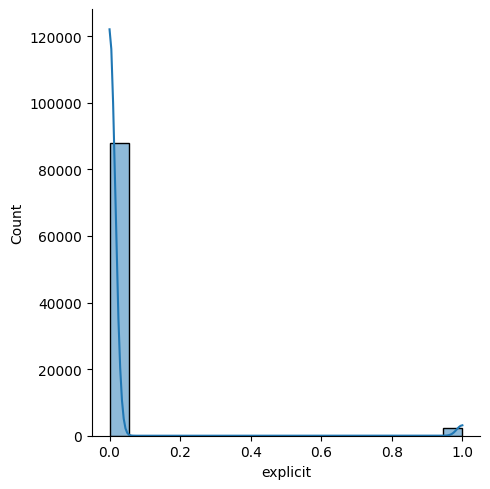

<Figure size 1000x500 with 0 Axes>

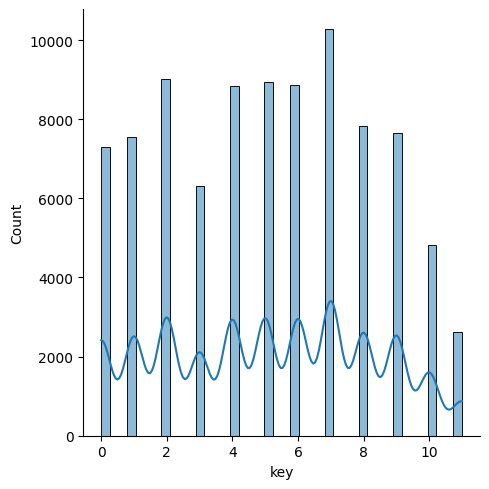

<Figure size 1000x500 with 0 Axes>

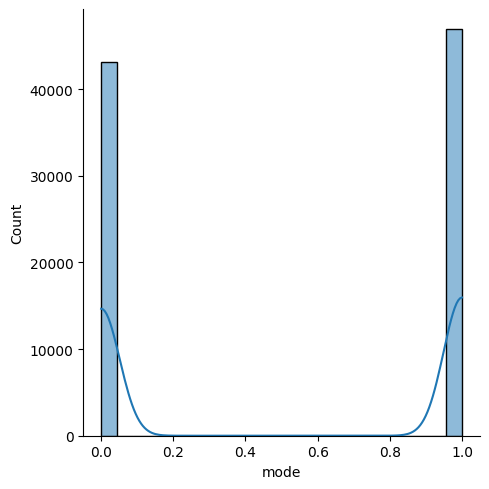

<Figure size 1000x500 with 0 Axes>

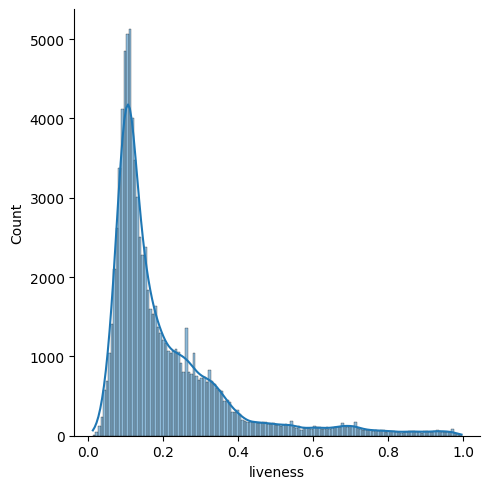

<Figure size 1000x500 with 0 Axes>

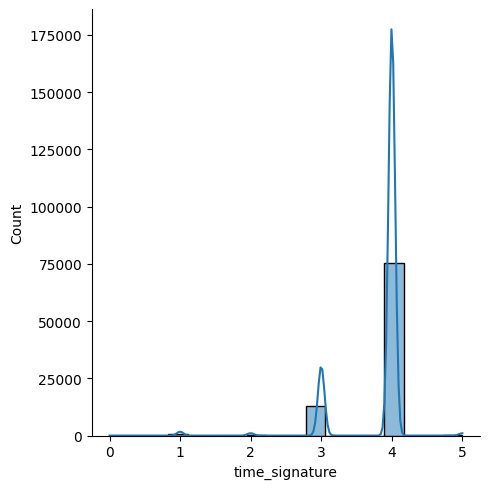

<Figure size 1000x500 with 0 Axes>

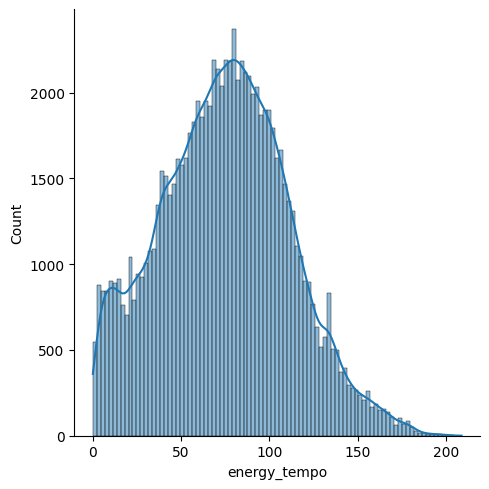

<Figure size 1000x500 with 0 Axes>

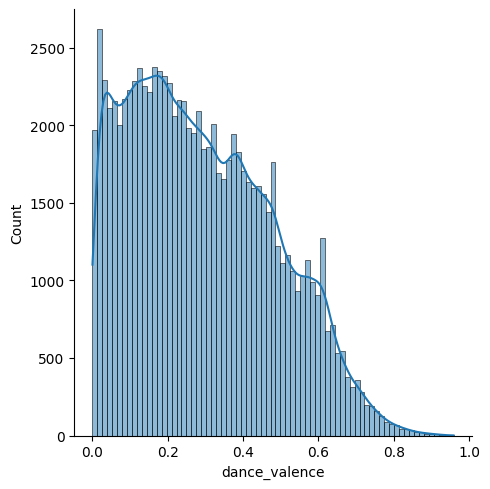

<Figure size 1000x500 with 0 Axes>

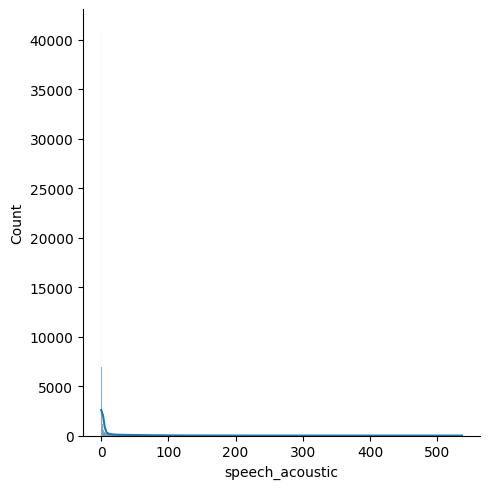

<Figure size 1000x500 with 0 Axes>

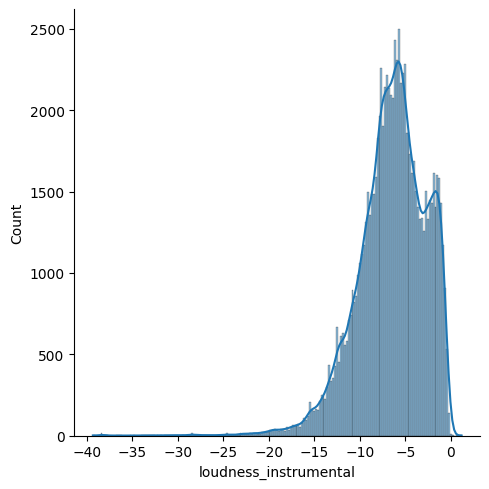

<Figure size 1000x500 with 0 Axes>

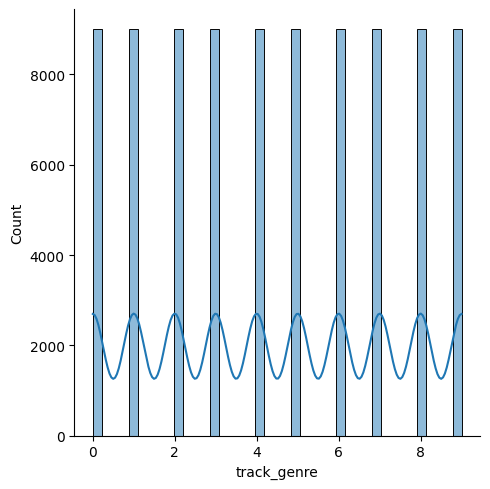

In [ ]:
#histogram of dataset one by one
features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.displot(music_dataset[feature], kde = True)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

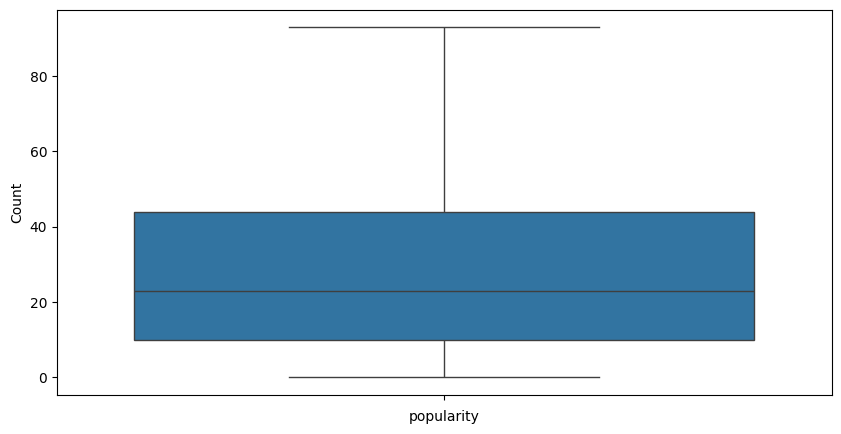

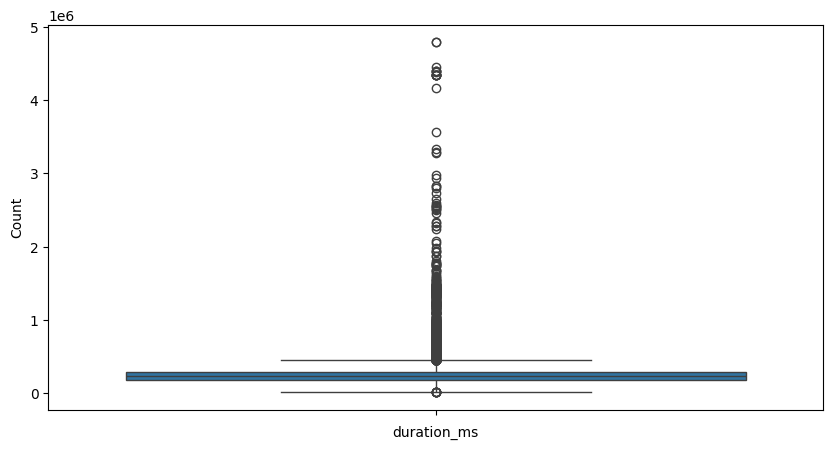

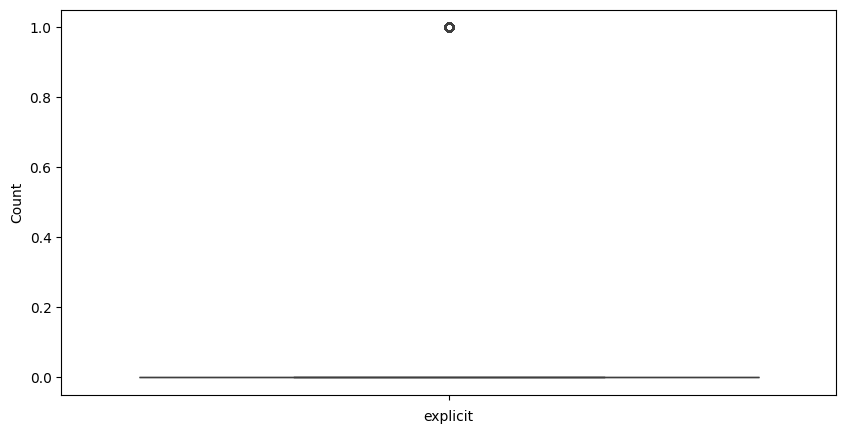

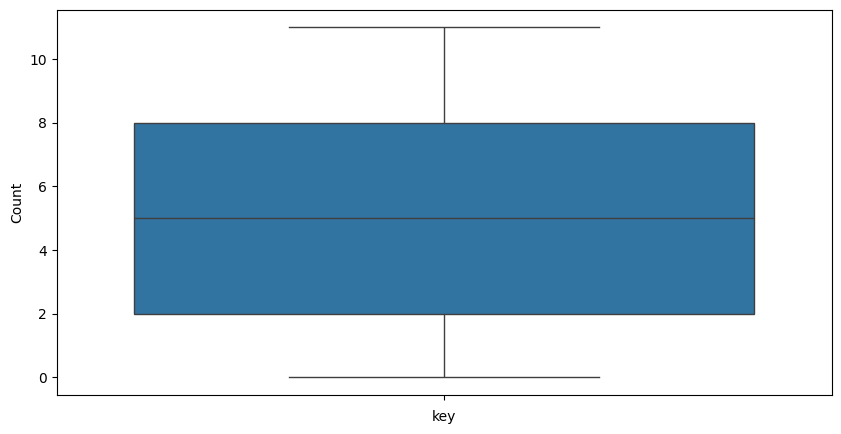

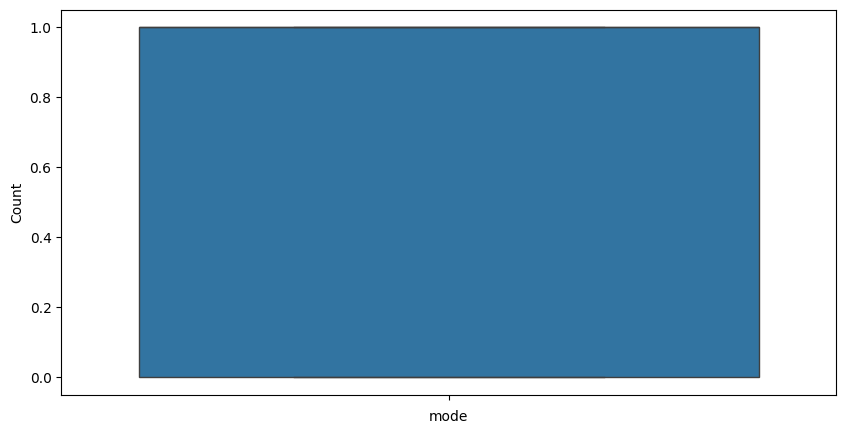

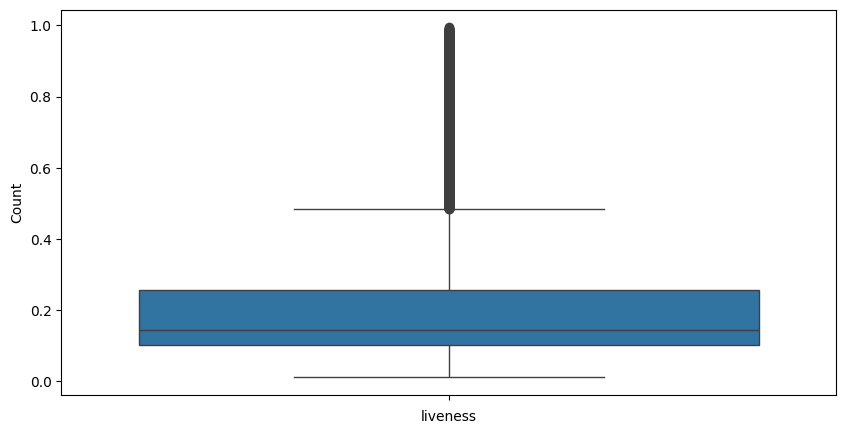

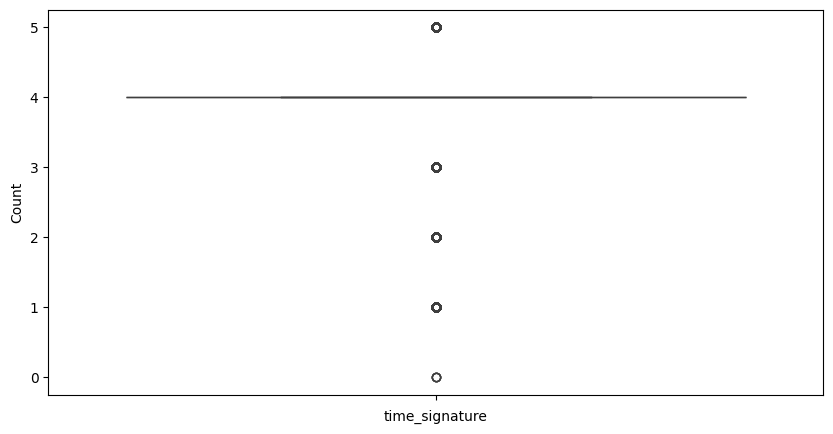

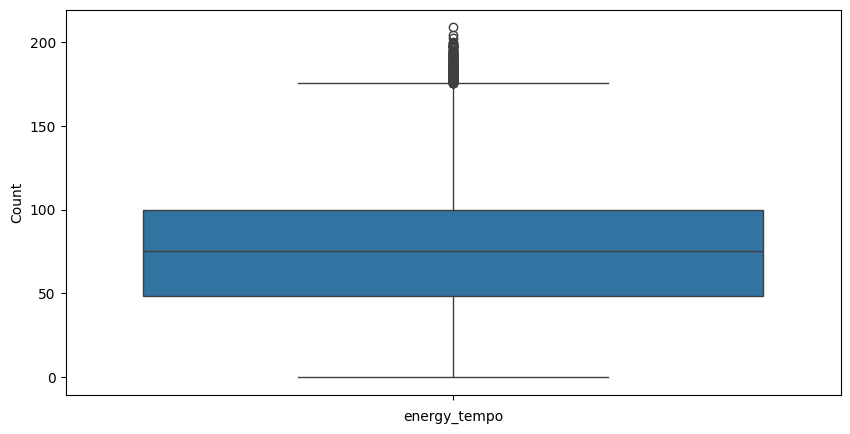

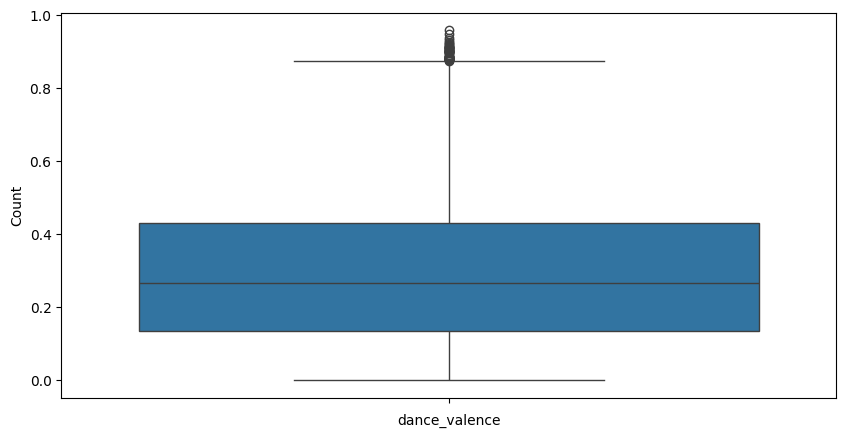

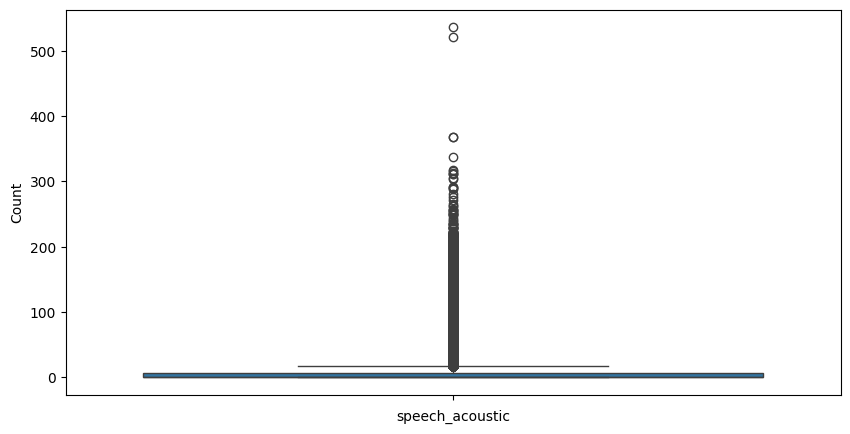

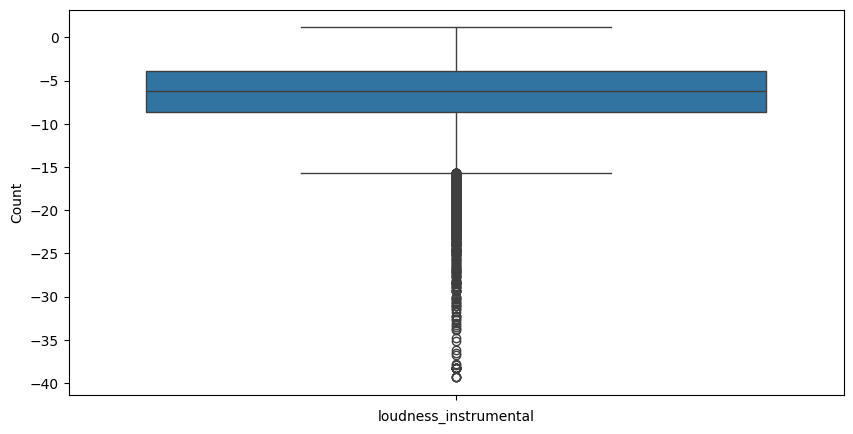

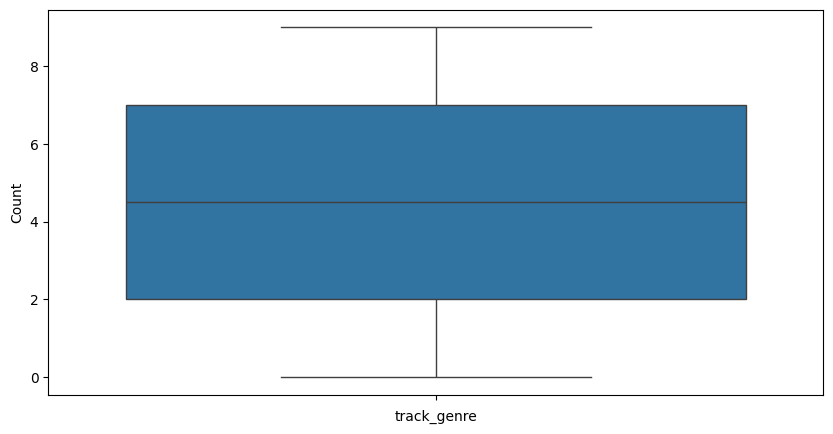

In [ ]:
#now finally box plot
features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(music_dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

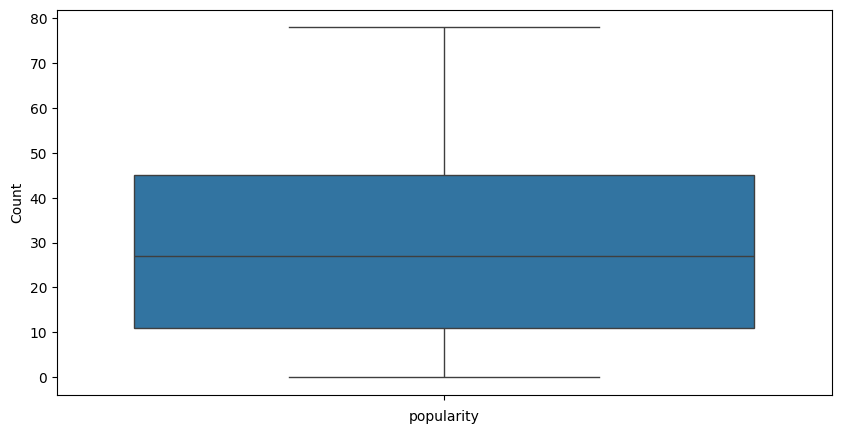

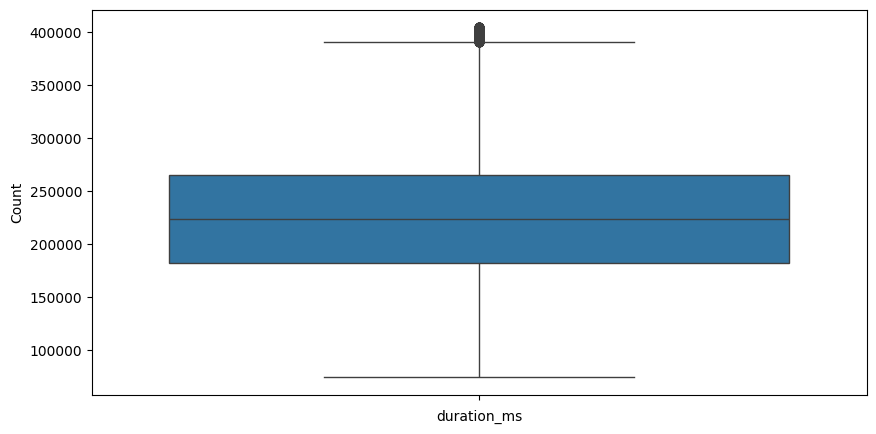

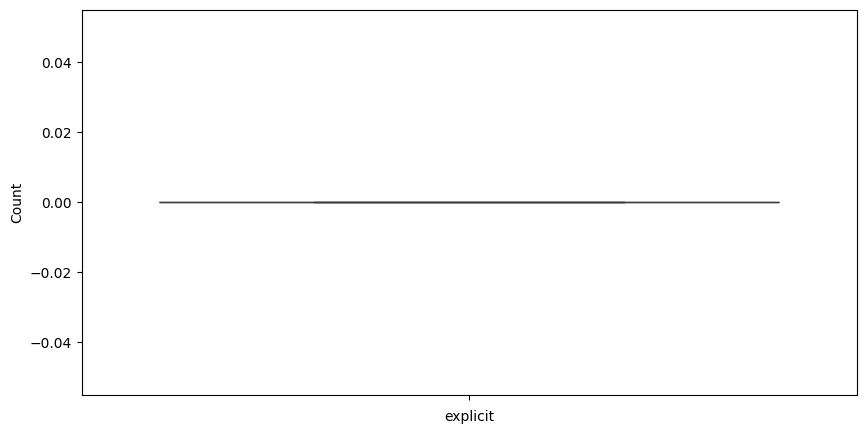

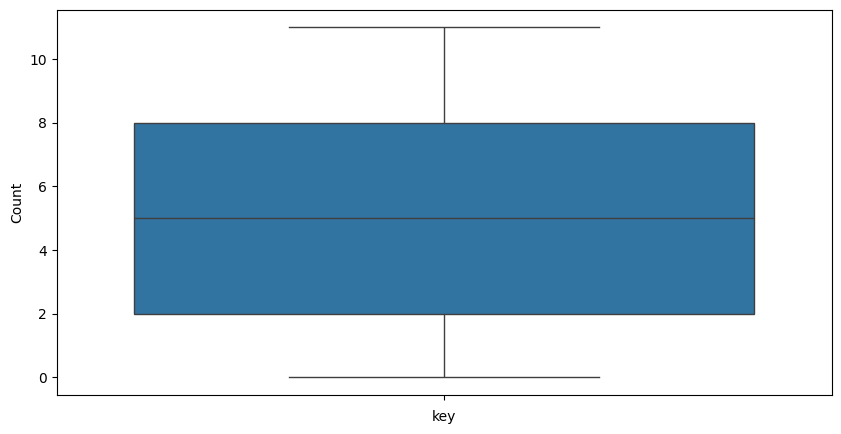

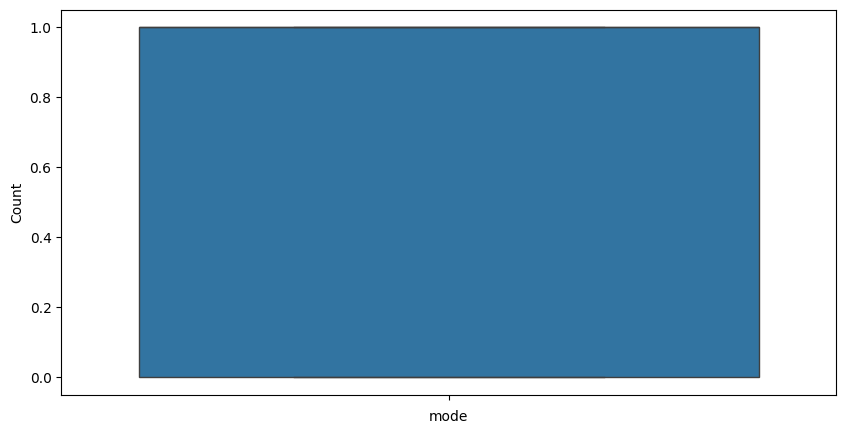

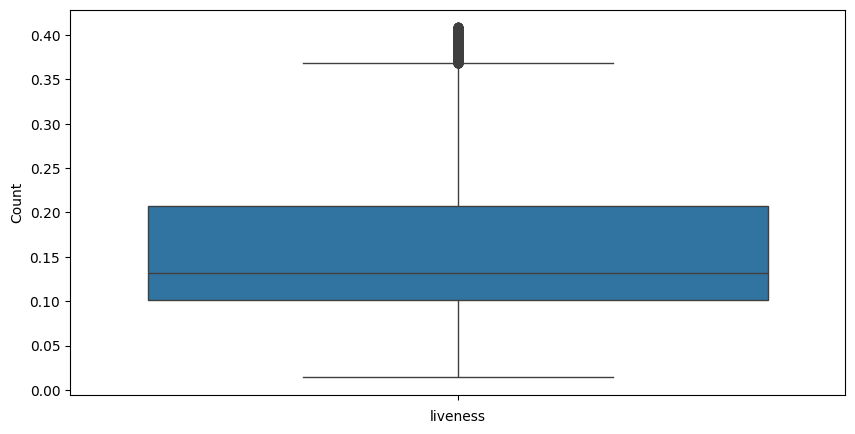

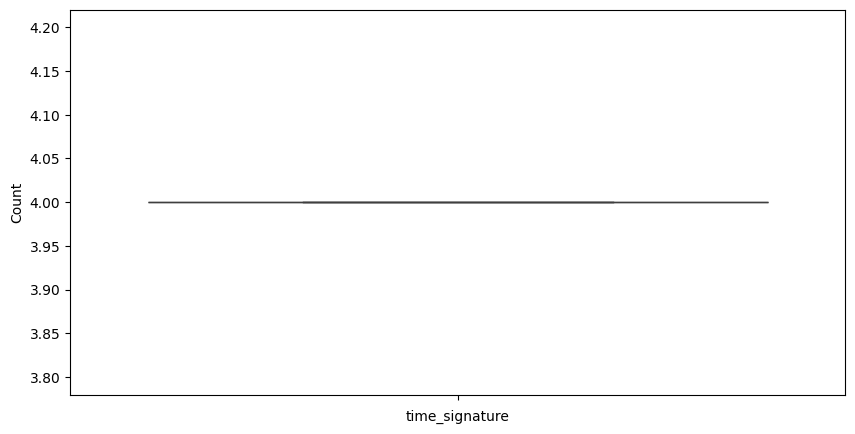

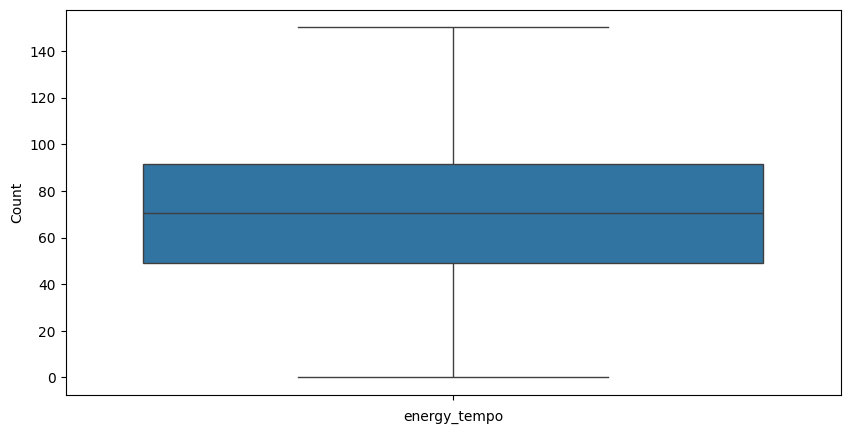

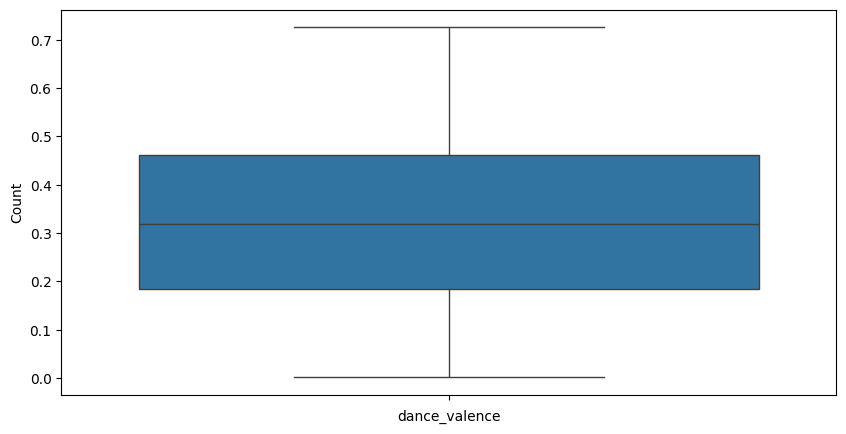

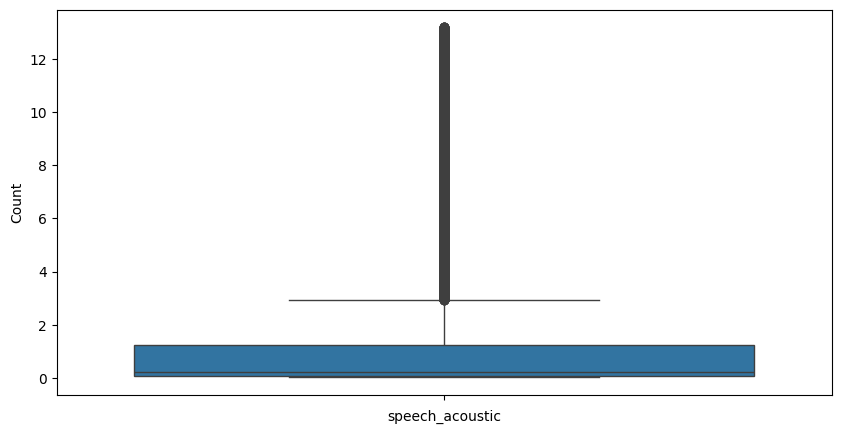

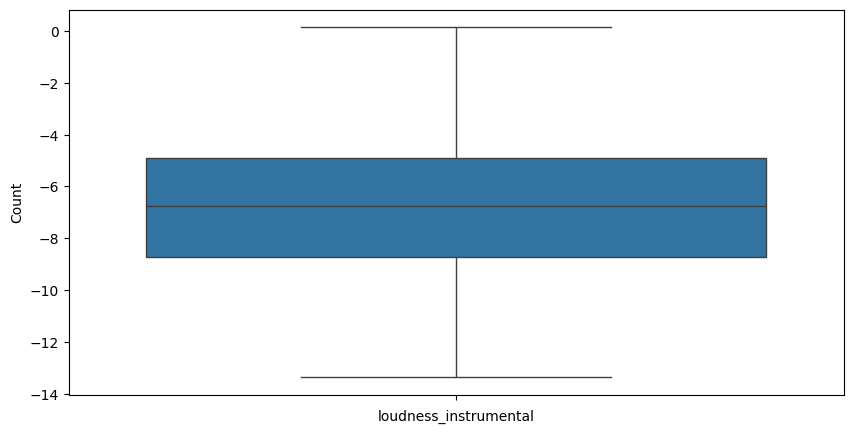

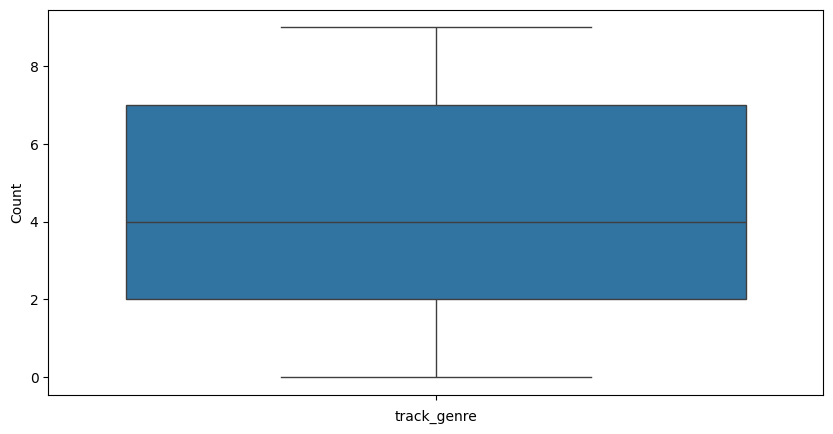

In [ ]:
#remove outliers
Q1 = music_dataset.quantile(0.25)
Q3 = music_dataset.quantile(0.75)
IQR = Q3 - Q1
music_dataset = music_dataset[~((music_dataset < (Q1 - 1.0 * IQR)) | (music_dataset > (Q3 + 1.0 * IQR))).any(axis=1)]

features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(music_dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [ ]:
#correlation matrix
correlationMatrix = music_dataset.corr()
correlationMatrix

,popularity,duration_ms,explicit,key,mode,liveness,time_signature,energy_tempo,dance_valence,speech_acoustic,loudness_instrumental,track_genre
popularity,1.000000,0.080334,NaN,-0.049827,-0.056926,-0.001166,NaN,0.023516,-0.155937,-0.038389,-0.121247,0.207341
duration_ms,0.080334,1.000000,NaN,-0.040272,-0.110017,-0.086752,NaN,0.113632,-0.119651,0.146373,-0.005397,0.022553
explicit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
key,-0.049827,-0.040272,NaN,1.000000,-0.047306,0.030041,NaN,0.068125,0.084650,0.034500,0.017581,-0.012289
mode,-0.056926,-0.110017,NaN,-0.047306,1.000000,0.006845,NaN,-0.099158,-0.114254,-0.144675,-0.073638,-0.145352
liveness,-0.001166,-0.086752,NaN,0.030041,0.006845,1.000000,NaN,0.128515,0.024122,0.018638,-0.038924,0.003536
time_signature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy_tempo,0.023516,0.113632,NaN,0.068125,-0.099158,0.128515,NaN,1.000000,0.381072,0.332323,0.266129,0.192731
dance_valence,-0.155937,-0.119651,NaN,0.084650,-0.114254,0.024122,NaN,0.381072,1.000000,0.108532,0.057484,0.088373
speech_acoustic,-0.038389,0.146373,NaN,0.034500,-0.144675,0.018638,NaN,0.332323,0.108532,1.000000,0.210252,0.032070


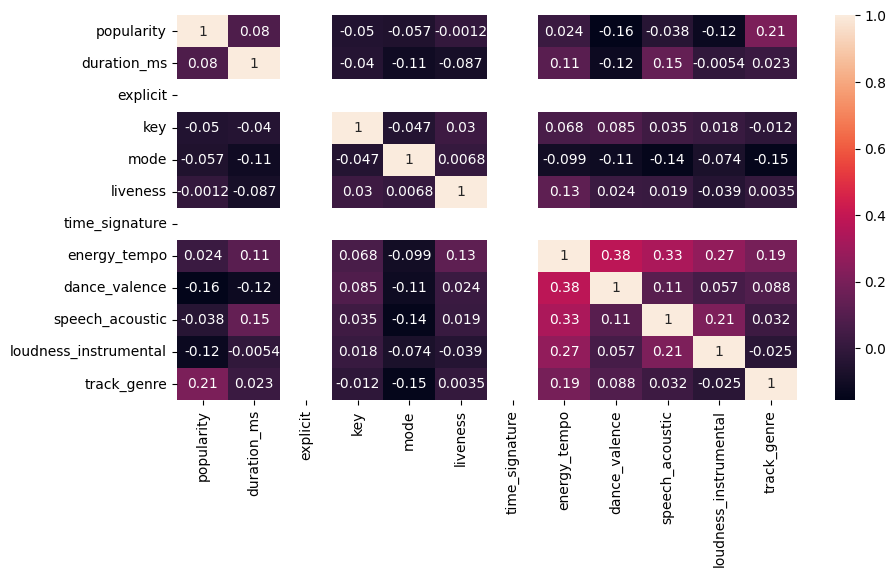

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(correlationMatrix, annot=True)
plt.show()

In [ ]:
#constant features
features = music_dataset.columns
for feature in features:
    if music_dataset[feature].std() == 0:
        print(feature)
        print(music_dataset[feature].std())
        print('\n')

explicit
0.0


time_signature
0.0




In [ ]:
print("Unique time_signature values:", music_dataset['time_signature'].unique())
print("Unique explicit values:", music_dataset['explicit'].unique())

Unique time_signature values: [4]
Unique explicit values: [0]


In [ ]:
#remove these useless constant features
music_dataset.drop(['explicit', 'time_signature'], axis = 1, inplace = True)
music_dataset

,popularity,duration_ms,key,mode,liveness,energy_tempo,dance_valence,speech_acoustic,loudness_instrumental,track_genre
0,73,230666,1,0,0.358000,40.529737,0.483340,4.307229,-6.745993,6
2,57,210826,0,1,0.117000,27.403188,0.052560,0.263981,-9.734000,6
5,58,214240,6,1,0.189000,47.146177,0.458208,0.362069,-8.807000,6
8,74,189613,0,1,0.151000,53.856432,0.418125,0.125085,-8.700000,6
9,56,205594,1,1,0.073500,49.864168,0.086632,0.069087,-6.741634,6
...,...,...,...,...,...,...,...,...,...,...
89987,35,180380,0,0,0.088465,77.653983,0.631268,0.066876,-3.511749,9
89988,19,202451,7,0,0.136107,90.480004,0.566364,1.341453,-4.410937,9
89993,21,312535,7,1,0.176699,91.521925,0.703279,0.206301,-6.165886,9
89997,17,270082,8,0,0.087741,89.226380,0.506021,0.537261,-1.808224,9


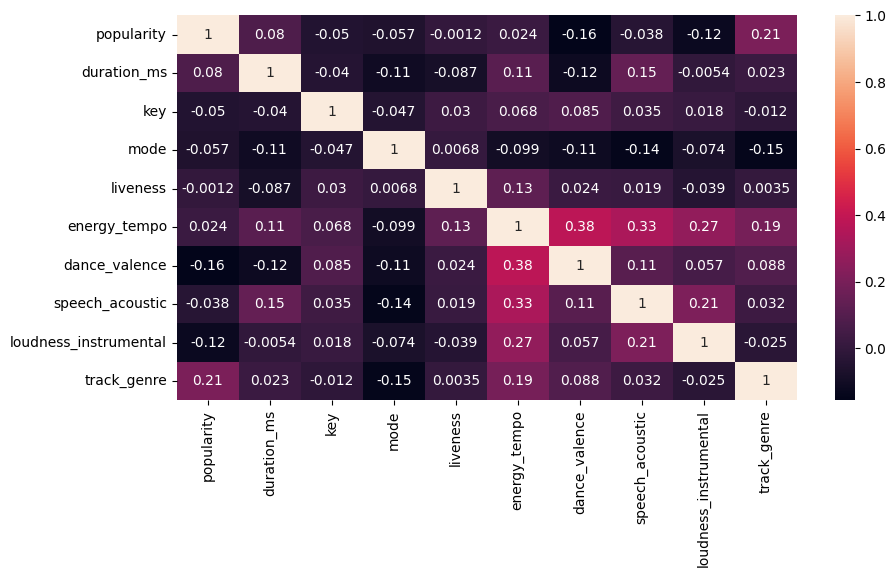

In [ ]:
correlationMatrix2 = music_dataset.corr()

plt.figure(figsize=(10, 5))
sns.heatmap(correlationMatrix2, annot=True)
plt.show()

Training the Model 💪🏋️

1. Logistic Regression

In [ ]:
X1 = music_dataset.drop('track_genre', axis = 1)
Y1 = music_dataset['track_genre']

pt = PowerTransformer()
X1 = pt.fit_transform(X1)

X1_train1, X1_test1, Y1_train1, Y1_test1 = train_test_split(X1, Y1, test_size = 0.2, random_state = 42)

In [ ]:
music_dataset

,popularity,duration_ms,key,mode,liveness,energy_tempo,dance_valence,speech_acoustic,loudness_instrumental,track_genre
0,73,230666,1,0,0.358000,40.529737,0.483340,4.307229,-6.745993,6
2,57,210826,0,1,0.117000,27.403188,0.052560,0.263981,-9.734000,6
5,58,214240,6,1,0.189000,47.146177,0.458208,0.362069,-8.807000,6
8,74,189613,0,1,0.151000,53.856432,0.418125,0.125085,-8.700000,6
9,56,205594,1,1,0.073500,49.864168,0.086632,0.069087,-6.741634,6
...,...,...,...,...,...,...,...,...,...,...
89987,35,180380,0,0,0.088465,77.653983,0.631268,0.066876,-3.511749,9
89988,19,202451,7,0,0.136107,90.480004,0.566364,1.341453,-4.410937,9
89993,21,312535,7,1,0.176699,91.521925,0.703279,0.206301,-6.165886,9
89997,17,270082,8,0,0.087741,89.226380,0.506021,0.537261,-1.808224,9


In [ ]:
lr_params = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs', 'saga'], 'max_iter': [1000]}

model1 = RandomizedSearchCV(LogisticRegression(multi_class='multinomial'), lr_params, cv=5, n_jobs=-1)
model1.fit(X1_train1, Y1_train1)

print("Best params:", model1.best_params_)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 1000, 'C': 10}


In [ ]:
model1 = LogisticRegression(C = 0.01, max_iter = 1000, multi_class = 'multinomial', penalty = 'l2', solver = 'saga')
model1.fit(X1_train1, Y1_train1)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=0.01, max_iter=1000, multi_class='multinomial',
                   solver='saga')

In [ ]:
#print actual values and predicted values
actual_values1 = Y1_test1
predicted_values1 = model1.predict(X1_test1)

print("Actual values:", actual_values1)
print("Predicted values:", predicted_values1)

Actual values: 44174    3
14451    6
82643    9
49804    3
40179    2
        ..
82369    9
78867    8
14495    6
39748    2
86925    9
Name: track_genre, Length: 9103, dtype: int64
Predicted values: [6 2 9 ... 3 2 9]


In [ ]:
#evaluation metrics
accuracy1 = accuracy_score(Y1_test1, predicted_values1)
precision1 = precision_score(Y1_test1, predicted_values1, average='macro')
recall1 = recall_score(Y1_test1, predicted_values1, average='macro')
f1_score1 = f1_score(Y1_test1, predicted_values1, average='macro')

print("Accuracy:", accuracy1 * 100)
print("Precision:", precision1 * 100)
print("Recall:", recall1 * 100)
print("F1 Score:", f1_score1 * 100)

Accuracy: 45.567395364165655
Precision: 45.59643823013285
Recall: 42.238369130664154
F1 Score: 42.22684855340411


In [ ]:
#classification report
print(classification_report(Y1_test1, predicted_values1))

              precision    recall  f1-score   support

           0       0.78      0.72      0.75       571
           1       0.68      0.58      0.63       568
           2       0.44      0.43      0.43      1232
           3       0.32      0.22      0.26      1195
           4       0.33      0.33      0.33       969
           5       0.33      0.04      0.07        73
           6       0.37      0.26      0.31       903
           7       0.50      0.74      0.59      1385
           8       0.31      0.26      0.29       995
           9       0.51      0.63      0.56      1212

    accuracy                           0.46      9103
   macro avg       0.46      0.42      0.42      9103
weighted avg       0.44      0.46      0.44      9103



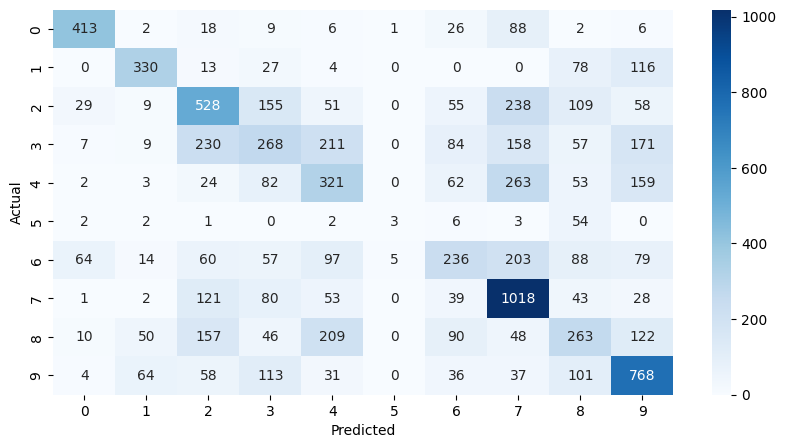

In [ ]:
#confusion matrix
cm = confusion_matrix(Y1_test1, predicted_values1)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

2. Decision Tree

In [ ]:
X2 = music_dataset.drop('track_genre', axis = 1)
Y2 = music_dataset['track_genre']

pt = PowerTransformer()
X2 = pt.fit_transform(X2)

X2_train2, X2_test2, Y2_train2, Y2_test2 = train_test_split(X2, Y2, test_size = 0.2, random_state = 42)

In [ ]:
music_dataset

,popularity,duration_ms,key,mode,liveness,energy_tempo,dance_valence,speech_acoustic,loudness_instrumental,track_genre
0,73,230666,1,0,0.358000,40.529737,0.483340,4.307229,-6.745993,6
2,57,210826,0,1,0.117000,27.403188,0.052560,0.263981,-9.734000,6
5,58,214240,6,1,0.189000,47.146177,0.458208,0.362069,-8.807000,6
8,74,189613,0,1,0.151000,53.856432,0.418125,0.125085,-8.700000,6
9,56,205594,1,1,0.073500,49.864168,0.086632,0.069087,-6.741634,6
...,...,...,...,...,...,...,...,...,...,...
89987,35,180380,0,0,0.088465,77.653983,0.631268,0.066876,-3.511749,9
89988,19,202451,7,0,0.136107,90.480004,0.566364,1.341453,-4.410937,9
89993,21,312535,7,1,0.176699,91.521925,0.703279,0.206301,-6.165886,9
89997,17,270082,8,0,0.087741,89.226380,0.506021,0.537261,-1.808224,9


In [ ]:
#hyoerparameter tuning
param_grid = {'max_depth': [3, 5, 10], 'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random']}

model2 = RandomizedSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
model2.fit(X2_train2, Y2_train2)

print("Best parameters:", model2.best_params_)
print("Best score:", model2.best_score_)

Best parameters: {'splitter': 'best', 'max_depth': 10, 'criterion': 'entropy'}
Best score: 0.642223354225148


In [ ]:
model2 = DecisionTreeClassifier(max_depth = 10, criterion = 'entropy', splitter = 'best')
model2.fit(X2_train2, Y2_train2)

DecisionTreeClassifier(criterion='entropy', max_depth=10)

In [ ]:
#actual values vs predicted values
actual_values2 = Y2_test2
predicted_values2 = model2.predict(X2_test2)

print("Actual values:", actual_values2)
print("Predicted values:", predicted_values2)

Actual values: 44174    3
14451    6
82643    9
49804    3
40179    2
        ..
82369    9
78867    8
14495    6
39748    2
86925    9
Name: track_genre, Length: 9103, dtype: int64
Predicted values: [3 6 9 ... 3 7 2]


In [ ]:
#evaluation metrics
accuracy2 = accuracy_score(Y2_test2, predicted_values2)
precision2 = precision_score(Y2_test2, predicted_values2, average='macro')
recall2 = recall_score(Y2_test2, predicted_values2, average='macro')
f1_score2 = f1_score(Y2_test2, predicted_values2, average='macro')

print("Accuracy:", accuracy2 * 100)
print("Precision:", precision2 * 100)
print("Recall:", recall2 * 100)
print("F1 Score:", f1_score2 * 100)

Accuracy: 64.8028122596946
Precision: 66.66453754205031
Recall: 64.97857927419417
F1 Score: 65.16512918675976


In [ ]:
#classification report
print(classification_report(Y2_test2, predicted_values2))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81       571
           1       0.78      0.82      0.80       568
           2       0.55      0.58      0.56      1232
           3       0.64      0.50      0.56      1195
           4       0.64      0.78      0.70       969
           5       0.68      0.56      0.62        73
           6       0.62      0.40      0.48       903
           7       0.64      0.74      0.69      1385
           8       0.65      0.52      0.58       995
           9       0.65      0.80      0.72      1212

    accuracy                           0.65      9103
   macro avg       0.67      0.65      0.65      9103
weighted avg       0.65      0.65      0.64      9103



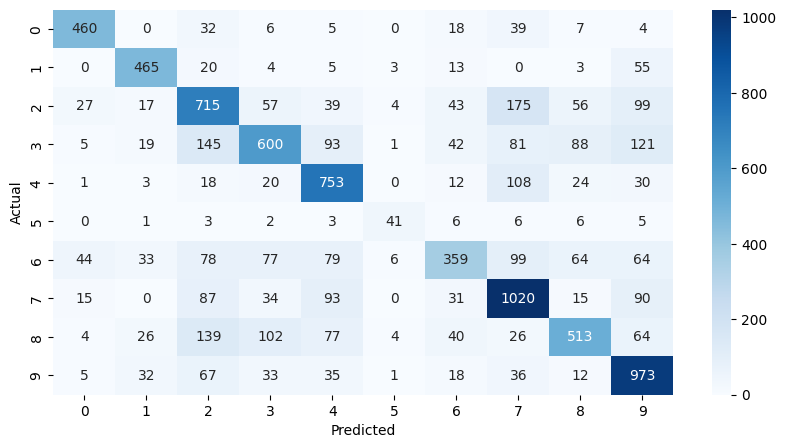

In [ ]:
#confusion matrix
cm = confusion_matrix(Y2_test2, predicted_values2)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

3. Naive Bayes

In [ ]:
X3 = music_dataset.drop('track_genre', axis = 1)
Y3 = music_dataset['track_genre']

pt = PowerTransformer()
X3 = pt.fit_transform(X3)

X3_train3, X3_test3, Y3_train3, Y3_test3 = train_test_split(X3, Y3, test_size = 0.2, random_state = 42)

In [ ]:
#hyperparameter tuning for naive bayes
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

model3 = RandomizedSearchCV(GaussianNB(), param_grid, cv=5)
model3.fit(X3_train3, Y3_train3)

print("Best parameters:", model3.best_params_)
print("Best score:", model3.best_score_)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'var_smoothing': 1e-09}
Best score: 0.5135261661935748


In [ ]:
model3 = GaussianNB(var_smoothing = 1e-09)
model3.fit(X3_train3, Y3_train3)

GaussianNB()

In [ ]:
#actual values vs predicted values
actual_values3 = Y3_test3
predicted_values3 = model3.predict(X3_test3)

print("Actual values:", actual_values3)
print("Predicted values:", predicted_values3)

Actual values: 44174    3
14451    6
82643    9
49804    3
40179    2
        ..
82369    9
78867    8
14495    6
39748    2
86925    9
Name: track_genre, Length: 9103, dtype: int64
Predicted values: [8 6 9 ... 3 7 9]


In [ ]:
#evaluation metrics
accuracy3 = accuracy_score(Y3_test3, predicted_values3)
precision3 = precision_score(Y3_test3, predicted_values3, average='macro')
recall3 = recall_score(Y3_test3, predicted_values3, average='macro')
f1_score3 = f1_score(Y3_test3, predicted_values3, average='macro')

print("Accuracy:", accuracy3 * 100)
print("Precision:", precision3 * 100)
print("Recall:", recall3 * 100)
print("F1 Score:", f1_score3 * 100)

Accuracy: 51.675271888388444
Precision: 51.53471669002598
Recall: 53.08977742646937
F1 Score: 50.31664005655281


In [ ]:
#classification report
print(classification_report(Y3_test3, predicted_values3))

              precision    recall  f1-score   support

           0       0.57      0.80      0.67       571
           1       0.70      0.72      0.71       568
           2       0.45      0.41      0.43      1232
           3       0.36      0.15      0.21      1195
           4       0.45      0.59      0.51       969
           5       0.47      0.52      0.49        73
           6       0.56      0.19      0.28       903
           7       0.50      0.76      0.61      1385
           8       0.45      0.45      0.45       995
           9       0.64      0.73      0.68      1212

    accuracy                           0.52      9103
   macro avg       0.52      0.53      0.50      9103
weighted avg       0.51      0.52      0.49      9103



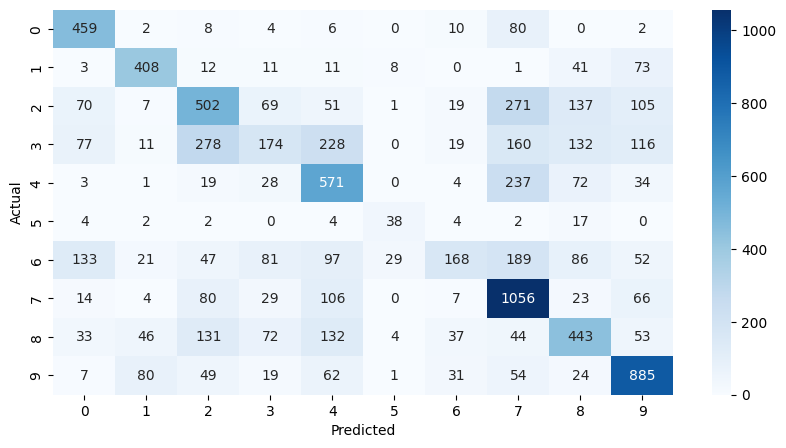

In [ ]:
#confusion matrix
cm = confusion_matrix(Y3_test3, predicted_values3)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

4. KNN

In [ ]:
X4 = music_dataset.drop('track_genre', axis = 1)
Y4 = music_dataset['track_genre']

pt = PowerTransformer()
X4 = pt.fit_transform(X4)

X4_train4, X4_test4, Y4_train4, Y4_test4 = train_test_split(X4, Y4, test_size = 0.2, random_state = 42)

In [ ]:
#hyperparameter tuning for knn
param_grid = {'n_neighbors': [3, 5, 10], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan', 'minkowski']}

model4 = RandomizedSearchCV(KNeighborsClassifier(), param_grid, cv=5)
model4.fit(X4_train4, Y4_train4)

print("Best parameters:", model4.best_params_)
print("Best score:", model4.best_score_)

Best parameters: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}
Best score: 0.8099748682025913


In [ ]:
model4 = KNeighborsClassifier(n_neighbors = 10, weights = 'distance', metric = 'euclidean')
model4.fit(X4_train4, Y4_train4)

KNeighborsClassifier(metric='euclidean', n_neighbors=10, weights='distance')

In [ ]:
#actual values vs predicted values
actual_values4 = Y4_test4
predicted_values4 = model4.predict(X4_test4)

print("Actual values:", actual_values4)
print("Predicted values:", predicted_values4)

Actual values: 44174    3
14451    6
82643    9
49804    3
40179    2
        ..
82369    9
78867    8
14495    6
39748    2
86925    9
Name: track_genre, Length: 9103, dtype: int64
Predicted values: [3 7 9 ... 6 2 9]


In [ ]:
#evaluation metrics
accuracy4 = accuracy_score(Y4_test4, predicted_values4)
precision4 = precision_score(Y4_test4, predicted_values4, average='macro')
recall4 = recall_score(Y4_test4, predicted_values4, average='macro')
f1_score4 = f1_score(Y4_test4, predicted_values4, average='macro')

print("Accuracy:", accuracy4 * 100)
print("Precision:", precision4 * 100)
print("Recall:", recall4 * 100)
print("F1 Score:", f1_score4 * 100)

Accuracy: 78.18301658793804
Precision: 79.34246859166377
Recall: 77.02279568166325
F1 Score: 77.35099790684454


In [ ]:
#classification report
print(classification_report(Y4_test4, predicted_values4))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       571
           1       0.88      0.87      0.87       568
           2       0.77      0.74      0.76      1232
           3       0.79      0.75      0.77      1195
           4       0.71      0.81      0.75       969
           5       0.77      0.67      0.72        73
           6       0.79      0.40      0.53       903
           7       0.74      0.90      0.81      1385
           8       0.80      0.80      0.80       995
           9       0.79      0.90      0.84      1212

    accuracy                           0.78      9103
   macro avg       0.79      0.77      0.77      9103
weighted avg       0.78      0.78      0.77      9103



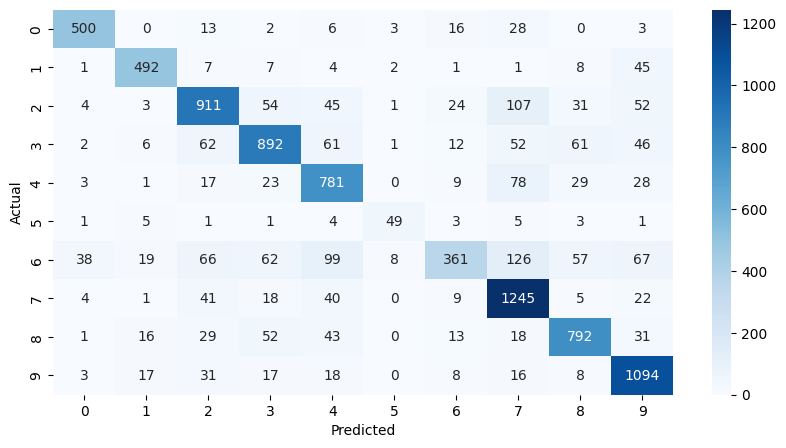

In [ ]:
#confusion matrix
cm = confusion_matrix(Y4_test4, predicted_values4)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

5. Random Forest

In [ ]:
X5 = music_dataset.drop('track_genre', axis = 1)
Y5 = music_dataset['track_genre']

pt = PowerTransformer()
X5 = pt.fit_transform(X5)

X5_train5, X5_test5, Y5_train5, Y5_test5 = train_test_split(X5, Y5, test_size = 0.2, random_state = 42)

In [ ]:
#hyperparameter tuning for Random Forest
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}

model5 = RandomizedSearchCV(RandomForestClassifier(), param_grid, cv=5)
model5.fit(X5_train5, Y5_train5)

print("Best parameters:", model5.best_params_)
print("Best score:", model5.best_score_)

Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}
Best score: 0.8102221888018221


In [ ]:
model5 = RandomForestClassifier(n_estimators = 200, max_depth = 20, min_samples_split = 5)
model5.fit(X5_train5, Y5_train5)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=200)

In [ ]:
#actual values vs predicted values
actual_values5 = Y5_test5
predicted_values5 = model5.predict(X5_test5)

print("Actual values:", actual_values5)
print("Predicted values:", predicted_values5)

Actual values: 44174    3
14451    6
82643    9
49804    3
40179    2
        ..
82369    9
78867    8
14495    6
39748    2
86925    9
Name: track_genre, Length: 9103, dtype: int64
Predicted values: [3 6 9 ... 6 2 9]


In [ ]:
#evaluation metrics
accuracy5 = accuracy_score(Y5_test5, predicted_values5)
precision5 = precision_score(Y5_test5, predicted_values5, average='macro')
recall5 = recall_score(Y5_test5, predicted_values5, average='macro')
f1_score5 = f1_score(Y5_test5, predicted_values5, average='macro')

print("Accuracy:", accuracy5 * 100)
print("Precision:", precision5 * 100)
print("Recall:", recall5 * 100)
print("F1 Score:", f1_score5 * 100)

Accuracy: 81.87410743710865
Precision: 83.33186841815306
Recall: 81.847121801541
F1 Score: 82.22716766021927


In [ ]:
#classification report
print(classification_report(Y5_test5, predicted_values5))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       571
           1       0.88      0.92      0.90       568
           2       0.82      0.77      0.79      1232
           3       0.82      0.74      0.78      1195
           4       0.77      0.89      0.82       969
           5       0.88      0.79      0.83        73
           6       0.79      0.57      0.67       903
           7       0.80      0.91      0.85      1385
           8       0.85      0.78      0.82       995
           9       0.81      0.92      0.86      1212

    accuracy                           0.82      9103
   macro avg       0.83      0.82      0.82      9103
weighted avg       0.82      0.82      0.82      9103



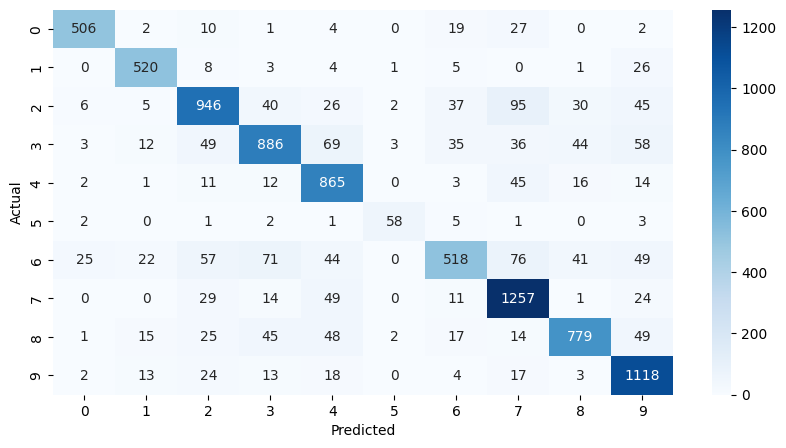

In [ ]:
#confusion matrix
cm = confusion_matrix(Y5_test5, predicted_values5)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

6. XGBoost

In [ ]:
# Training the Model 💪🏋️
X6 = music_dataset.drop('track_genre', axis=1)
y6 = music_dataset['track_genre']

pt = PowerTransformer()
X6 = pt.fit_transform(X6)

X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42)

In [ ]:
xgb_params = {'n_estimators': [200, 300], 'max_depth': [6, 8], 'learning_rate': [0.01, 0.1], 'subsample': [0.8, 0.9]}

model6 = RandomizedSearchCV(XGBClassifier(), xgb_params, cv=5, n_jobs=-1)
model6.fit(X6_train, y6_train)

print("Best params:", model6.best_params_)
print("best score:", model6.best_score_ * 100, "%")

Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}
best score: 84.01856169701082 %


In [ ]:
model6 = XGBClassifier(learning_rate = 0.1, max_depth = 8, n_estimators = 300, subsample = 0.8)
model6.fit(X6_train, y6_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
actual_values = y6_test
predicted_values = model6.predict(X6_test)

print("Actual values:", actual_values)
print("Predicted values:", predicted_values)

Actual values: 44174    3
14451    6
82643    9
49804    3
40179    2
        ..
82369    9
78867    8
14495    6
39748    2
86925    9
Name: track_genre, Length: 9103, dtype: int64
Predicted values: [3 6 9 ... 6 2 9]


In [ ]:
accuracy6 = accuracy_score(y6_test, predicted_values)
precision6 = precision_score(y6_test, predicted_values, average='macro')
recall6 = recall_score(y6_test, predicted_values, average='macro')

print("Accuracy:", accuracy6 * 100)
print("Precision:", precision6 * 100)
print("Recall:", recall6 * 100)

Accuracy: 85.78490607492036
Precision: 86.85973559413569
Recall: 85.73018562458496


In [ ]:
#print classification report
print(classification_report(y6_test, predicted_values))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       571
           1       0.93      0.95      0.94       568
           2       0.84      0.82      0.83      1232
           3       0.83      0.81      0.82      1195
           4       0.83      0.92      0.87       969
           5       0.91      0.84      0.87        73
           6       0.82      0.61      0.70       903
           7       0.85      0.94      0.89      1385
           8       0.88      0.84      0.86       995
           9       0.88      0.94      0.91      1212

    accuracy                           0.86      9103
   macro avg       0.87      0.86      0.86      9103
weighted avg       0.86      0.86      0.86      9103



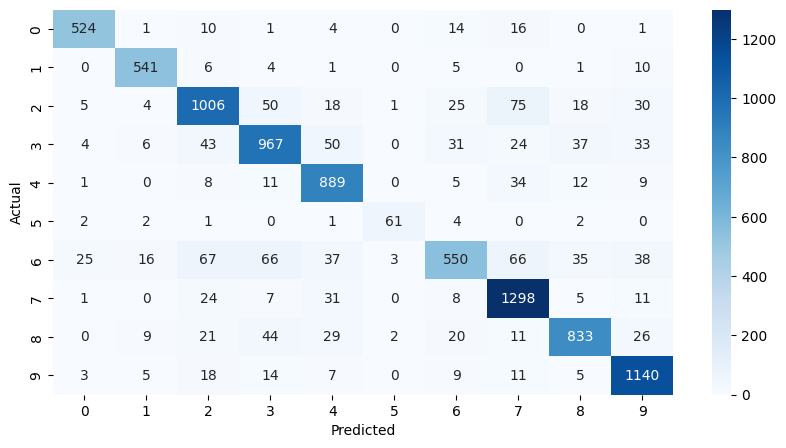

In [ ]:
#confusion matrix
cm = confusion_matrix(y6_test, predicted_values)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#dump all .pkl models
jb.dump(model1, 'lr_model.pkl')
jb.dump(model2, 'dt_model.pkl')
jb.dump(model3, 'nb_model.pkl')
jb.dump(model4, 'knn_model.pkl')
jb.dump(model5, 'rf_model.pkl')
jb.dump(model6, 'xgb_model.pkl')

['xgb_model.pkl']

In [ ]:
%%writefile spotify_genre_app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# Genre mapping
GENRE_MAPPING = {
    0: 'rock', 1: 'pop', 2: 'metal', 3: 'electronic',
    4: 'hiphop', 5: 'jazz', 6: 'classical', 7: 'folk',
    8: 'reggae', 9: 'latin', 10: 'world', 11: 'other'
}

# Load all models
@st.cache_resource
def load_models():
    return {
        'Random Forest': joblib.load('rf_model.pkl'),
        'Logistic Regression': joblib.load('lr_model.pkl'),
        'XGBoost': joblib.load('xgb_model.pkl'),
        'Decision Tree': joblib.load('dt_model.pkl')
    }

# Load sample data
@st.cache_data
def load_data():
    return pd.read_csv('Spotify Dataset.csv', nrows=20000)

def show_data_tab(df):
    st.header("Dataset Overview")

    col1, col2 = st.columns(2)
    with col1:
        st.write("First 10 rows:")
        st.dataframe(df.head(10))
    with col2:
        st.write("Dataset info:")
        buffer = io.StringIO()
        df.info(buf=buffer)
        st.text(buffer.getvalue())

    st.write("Descriptive statistics:")
    st.dataframe(df.describe())

def show_visualizations_tab(df):
    st.header("Data Visualizations")

    plot_type = st.selectbox("Choose visualization type:",
                           ["Histogram", "Box Plot", "Correlation Heatmap"])

    if plot_type == "Histogram":
        feature = st.selectbox("Select feature:", df.select_dtypes(include=np.number).columns)
        plt.figure(figsize=(10, 5))
        sns.histplot(df[feature], kde=True)
        st.pyplot(plt)

    elif plot_type == "Box Plot":
        feature = st.selectbox("Select feature:", df.select_dtypes(include=np.number).columns)
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=df[feature])
        st.pyplot(plt)

    elif plot_type == "Correlation Heatmap":
        plt.figure(figsize=(12, 8))
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
        st.pyplot(plt)

def show_prediction_tab(models):
    st.header("Genre Prediction")

    # Model selection
    model_name = st.selectbox("Choose model:", list(models.keys()))
    model = models[model_name]

    # User input
    with st.expander("Input Features", expanded=True):
        col1, col2 = st.columns(2)

        with col1:
            energy_tempo = st.slider('Energy × Tempo', 0.0, 100.0, 50.0)
            dance_valence = st.slider('Danceability × Valence', 0.0, 1.0, 0.5)
            speech_acoustic = st.slider('Speechiness / Acousticness', 0.0, 100.0, 1.0)
            loudness_instrumental = st.slider('Loudness × (1 - Instrumentalness)', -60.0, 0.0, -10.0)

        with col2:
            liveness_tempo = st.slider('Liveness × Tempo', 0.0, 1.0, 0.5)
            key = st.slider('Key (0=C, 1=C#...)', 0, 11, 5)
            mode = st.selectbox('Mode', [0, 1])
            duration_ms = st.slider('Duration (ms)', 0, 600000, 180000)
            popularity = st.slider('Popularity', 0, 100, 50)

    # Prepare input DataFrame
    input_data = {
        'energy_tempo': energy_tempo,
        'dance_valence': dance_valence,
        'speech_acoustic': speech_acoustic,
        'loudness_instrumental': loudness_instrumental,
        'liveness_tempo': liveness_tempo,
        'key': key,
        'mode': mode,
        'duration_ms': duration_ms,
        'popularity': popularity
    }
    input_df = pd.DataFrame([input_data])

    if st.button('Predict Genre'):
        # Preprocess input
        pt = PowerTransformer()
        X = pt.fit_transform(input_df)

        # Predict
        prediction = model.predict(X)[0]
        genre = GENRE_MAPPING.get(prediction, 'unknown')

        # Display results
        st.success(f"Predicted Genre: **{genre.upper()}**")

        # Show probabilities if available
        if hasattr(model, 'predict_proba'):
            st.subheader("Prediction Probabilities")
            probs = model.predict_proba(X)[0]

            prob_df = pd.DataFrame({
                'Genre': [GENRE_MAPPING[i] for i in range(len(probs))],
                'Probability': probs
            }).sort_values('Probability', ascending=False)

            st.dataframe(prob_df.style.format({'Probability': '{:.2%}'}))

            # Plot probabilities
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Probability', y='Genre', data=prob_df, palette='viridis')
            plt.title('Genre Prediction Probabilities')
            st.pyplot(plt)

def main():
    st.set_page_config(layout="wide", page_title="Spotify Genre Classifier")
    st.title("🎵 Spotify Music Genre Analysis")

    # Load data and models
    df = load_data()
    models = load_models()

    # Create tabs
    tab1, tab2, tab3 = st.tabs(["Dataset", "Visualizations", "Predictions"])

    with tab1:
        show_data_tab(df)

    with tab2:
        show_visualizations_tab(df)

    with tab3:
        show_prediction_tab(models)

if __name__ == "__main__":
    import io
    main()

Overwriting spotify_genre_app.py


In [ ]:
from pyngrok import ngrok

!ngrok authtoken 30dLxqJ7zHQFeiIpbFMsX6Ot6wm_6UQQTqwrCv3kjoe3yeYUZ

!streamlit run spotify_genre_app.py --server.port 8501 --server.address=0.0.0.0 &>/dev/null &

try:
    public_url = ngrok.connect(addr='8501', proto='http', bind_tls=True)
    print("Your app is live at:", public_url)
except Exception as e:
    print("Error creating tunnel:", e)
    print("\nAlternative: Use Colab's built-in preview:")
    print("1. Wait for Streamlit to start")
    print("2. Click the '>' icon next to the output")
    print("3. Select 'Preview on port 8501'")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Your app is live at: NgrokTunnel: "https://d916e259f8ae.ngrok-free.app" -> "http://localhost:8501"
